In [0]:
%sql
CREATE CATALOG retail_catalog;

In [0]:
%sql
SHOW CATALOGS;

catalog
airline_catalog
ext_catalog
main
managed_catalog
my-first-bronze-catalog
retail_catalog
samples
system


In [0]:
%sql
USE CATALOG retail_catalog;

CREATE SCHEMA retail_analytics;

In [0]:
%sql
SHOW SCHEMAS IN retail_catalog;

databaseName
default
information_schema
retail_analytics


In [0]:
%sql
CREATE VOLUME retail_catalog.retail_analytics.retail_volume;

In [0]:
%sql
SHOW VOLUMES IN retail_catalog.retail_analytics;

database,volume_name
retail_analytics,retail_volume


In [0]:
spark.sql("USE CATALOG retail_catalog")
spark.sql("USE SCHEMA retail_analytics")

DataFrame[]

In [0]:
customers_path = "/Volumes/retail_catalog/retail_analytics/retail_volume/customers.csv"

products_path = "/Volumes/retail_catalog/retail_analytics/retail_volume/products.csv"

orders_path = "/Volumes/retail_catalog/retail_analytics/retail_volume/orders.csv"

preferences_path = "/Volumes/retail_catalog/retail_analytics/retail_volume/customer_preferences.json"

In [0]:
customers_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(customers_path)
)

display(customers_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
products_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(products_path)
)

display(products_df)

product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


In [0]:
orders_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(orders_path)
)

display(orders_df)

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
preferences_df = (
    spark.read
    .option("multiline", "true")
    .json(preferences_path)
)

display(preferences_df)

customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
customers_df.printSchema()

products_df.printSchema()

orders_df.printSchema()

preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.bronze_customers"
    )

In [0]:
products_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.bronze_products"
    )

In [0]:
orders_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.bronze_orders"
    )

In [0]:
preferences_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.bronze_preferences"
    )

## Cleaning & Transformation

In [0]:
customers_df = customers_df.na.fill("Unknown")

products_df = products_df.na.fill("Unknown")

orders_df = orders_df.na.fill("Unknown")

In [0]:
from pyspark.sql.functions import col

preferences_flat = preferences_df.select(
    col("customer_id"),
    col("preferred_channel"),
    col("loyalty.tier").alias("loyalty_tier"),
    col("loyalty.points").alias("loyalty_points")
)

In [0]:
customer_pref_df = customers_df.join(
    preferences_flat,
    "customer_id",
    "left"
)

In [0]:
orders_customer_df = orders_df.join(
    customer_pref_df,
    "customer_id",
    "left"
)

In [0]:
final_df = orders_customer_df.join(
    products_df,
    "product_id",
    "left"
)

In [0]:
from pyspark.sql.functions import *

final_df = final_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

In [0]:
final_df = final_df.withColumn(
    "order_month",
    date_format(
        to_date("order_date"),
        "yyyy-MM"
    )
)

In [0]:
final_df = final_df.withColumn(
    "customer_segment",
    when(
        col("customer_type")=="Premium",
        "High Value"
    ).otherwise("Standard Value")
)

In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.silver_orders"
    )

## Spark SQL

In [0]:
final_df.createOrReplaceTempView(
    "retail_sales"
)

In [0]:
%sql
SELECT SUM(revenue) total_revenue
FROM retail_sales;

total_revenue
336000


In [0]:
%sql
SELECT city,
SUM(revenue) revenue
FROM retail_sales
GROUP BY city
ORDER BY revenue DESC;

city,revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
%sql
SELECT category,
SUM(revenue) revenue
FROM retail_sales
GROUP BY category;

category,revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
%sql
SELECT
customer_name,
SUM(revenue) revenue
FROM retail_sales
GROUP BY customer_name
ORDER BY revenue DESC;

customer_name,revenue
Rahul Sharma,90000
Sneha Patel,89000
Priya Reddy,50000
Arjun Verma,45000
Amit Kumar,21000
Farhan Ali,18000
Meera Nair,15000
Neha Singh,8000


In [0]:
%sql
SELECT *
FROM retail_sales
WHERE status='Completed';

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,2026-06,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,2026-06,High Value


## Window Functions

In [0]:
from pyspark.sql.window import Window

product_rank = final_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

product_rank = product_rank.withColumn(
    "rank",
    rank().over(
        Window.orderBy(
            desc("revenue")
        )
    )
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
customer_rank = final_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("revenue")
)

customer_rank = customer_rank.withColumn(
    "rank",
    rank().over(
        Window.orderBy(
            desc("revenue")
        )
    )
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
customer_rank.filter(
    col("rank")<=3
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------+-------+----+
|customer_name|revenue|rank|
+-------------+-------+----+
| Rahul Sharma|  90000|   1|
|  Sneha Patel|  89000|   2|
|  Priya Reddy|  50000|   3|
+-------------+-------+----+



In [0]:
category_rev = final_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

In [0]:
w = Window.partitionBy(
    "category"
).orderBy(
    desc("revenue")
)

In [0]:
top_product = category_rev.withColumn(
    "rank",
    rank().over(w)
).filter(
    col("rank")==1
)

In [0]:
running_df = final_df.withColumn(
    "running_revenue",
    sum("revenue").over(
        Window.orderBy("order_date")
    )
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
running_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+---------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|running_revenue|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+---------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Laptop|Electronics|     65000|  65000|    2026-06|      High Value|         115000|
|   

## Delta Lake

In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        "retail_catalog.retail_analytics.delta_table_saveastable"
    )

In [0]:
%sql
CREATE TABLE retail_catalog.retail_analytics.delta_sql
USING DELTA
AS
SELECT *
FROM retail_sales;

num_affected_rows,num_inserted_rows


In [0]:
%sql
DESCRIBE HISTORY retail_catalog.retail_analytics.delta_sql

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T05:55:55.000Z,143016486184747,atsthasneem@gmail.com,CREATE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(417739707803760),8da04268-5d24-4790-a346-52b41b63ed99,0622-034211-f57zxtke-v2n,null,WriteSerializable,true,"Map(numFiles -> 1, numOutputRows -> 10, numOutputBytes -> 5967)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
SELECT *
FROM retail_catalog.retail_analytics.delta_sql
VERSION AS OF 0;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,2026-06,High Value


In [0]:
updated_data = [
("C101","Rahul Sharma","Chennai","Tamil Nadu","Premium")
]

In [0]:
updated_df = spark.createDataFrame(
    updated_data,
    customers_df.columns
)

In [0]:
updated_df.createOrReplaceTempView(
    "customer_updates"
)

In [0]:
%sql
select * from customer_updates;

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Chennai,Tamil Nadu,Premium


In [0]:
%sql
MERGE INTO retail_catalog.retail_analytics.bronze_customers t
USING customer_updates s
ON t.customer_id=s.customer_id

WHEN MATCHED THEN UPDATE SET *

WHEN NOT MATCHED THEN INSERT *;

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
1,1,0,0


In [0]:
%sql
DESCRIBE HISTORY retail_catalog.retail_analytics.bronze_customers;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T05:58:24.000Z,143016486184747,atsthasneem@gmail.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(417739707803760),267dd9e7-98e5-4551-8f9a-0452a11a0fa9,0622-034211-f57zxtke-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 2, numRemovedBytes -> 3841, p25FileSize -> 2073, numDeletionVectorsRemoved -> 1, minFileSize -> 2073, numAddedFiles -> 1, maxFileSize -> 2073, p75FileSize -> 2073, p50FileSize -> 2073, numAddedBytes -> 2073)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T05:58:22.000Z,143016486184747,atsthasneem@gmail.com,MERGE,"Map(predicate -> [""(customer_id#16808 = customer_id#16793)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(417739707803760),267dd9e7-98e5-4551-8f9a-0452a11a0fa9,0622-034211-f57zxtke-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 1771, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 1, executionTimeMs -> 5073, materializeSourceTimeMs -> 206, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2715, numTargetRowsUpdated -> 1, numOutputRows -> 1, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2003)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T05:48:01.000Z,143016486184747,atsthasneem@gmail.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(417739707803760),5ca6080e-4faa-4662-9125-54b169f5606a,0622-034211-f57zxtke-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2070)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql
OPTIMIZE retail_catalog.retail_analytics.silver_orders;

path,metrics
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/29fda7ad-238b-4ad4-b4c7-958d3be27981,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782107954523, 1782107955015, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE retail_catalog.retail_analytics.silver_orders
ZORDER BY(city);

path,metrics
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/29fda7ad-238b-4ad4-b4c7-958d3be27981,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5967), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782107978134, 1782107978689, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
VACUUM retail_catalog.retail_analytics.silver_orders
RETAIN 168 HOURS;

path
abfss://metastore@atsdatabricksunity.dfs.core.windows.net/9b7405bb-8507-45c6-b943-4779a4db7886/tables/29fda7ad-238b-4ad4-b4c7-958d3be27981


## Visualization

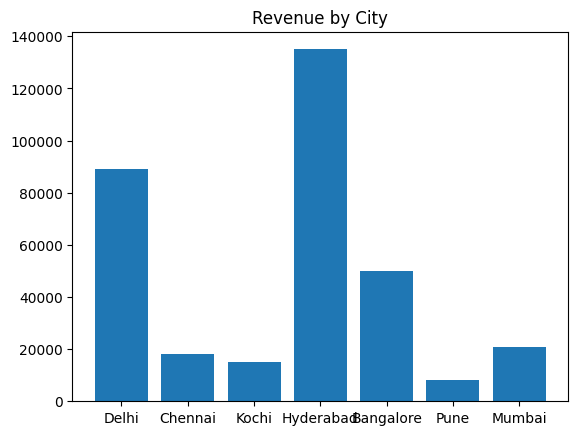

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

city_df = final_df.groupBy("city") \
    .agg(sum("revenue").alias("revenue"))

pdf = city_df.toPandas()

plt.bar(
    pdf["city"],
    pdf["revenue"]
)
plt.title("Revenue by City")
plt.show()

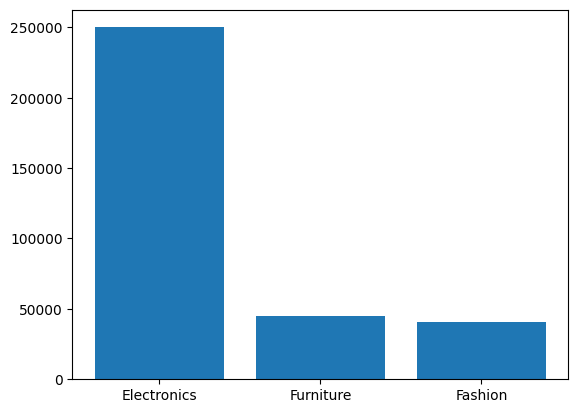

In [0]:
category_df = final_df.groupBy(
    "category"
).agg(
    sum("revenue").alias("revenue")
)

pdf = category_df.toPandas()

plt.bar(
    pdf["category"],
    pdf["revenue"]
)
plt.show()

In [0]:
status_df = final_df.groupBy(
    "status"
).count()

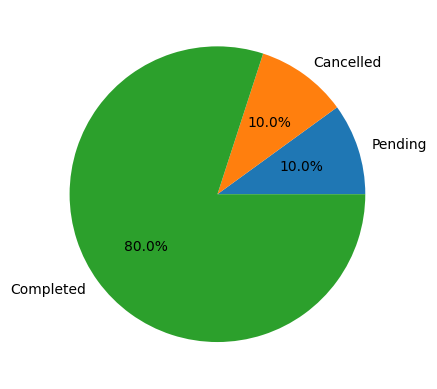

In [0]:
pdf = status_df.toPandas()

plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)

plt.show()

In [0]:
top_products = final_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

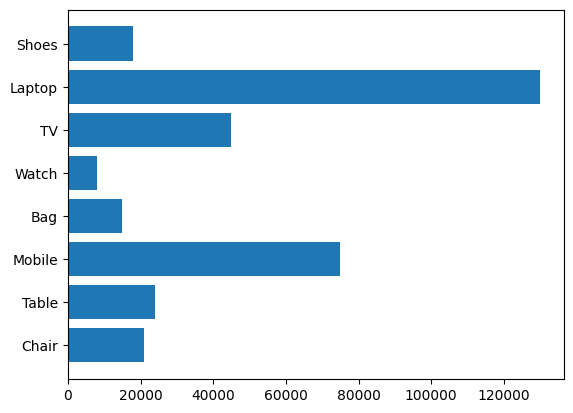

In [0]:
pdf = top_products.toPandas()

plt.barh(
    pdf["product_name"],
    pdf["revenue"]
)
plt.show()

In [0]:
trend = final_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("revenue")
)

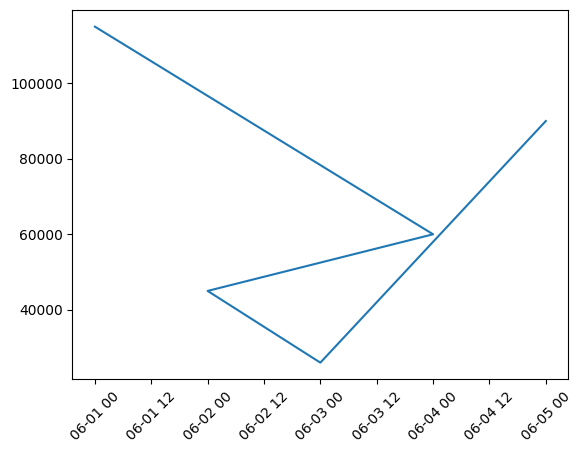

In [0]:
pdf = trend.toPandas()

plt.plot(
    pdf["order_date"],
    pdf["revenue"]
)

plt.xticks(rotation=45)
plt.show()

## Tables and Views

In [0]:
%sql
CREATE TABLE retail_catalog.retail_analytics.managed_sales
USING DELTA
AS
SELECT *
FROM retail_sales;

num_affected_rows,num_inserted_rows


In [0]:
%sql
CREATE OR REPLACE TEMP VIEW temp_sales AS
SELECT *
FROM retail_sales;

In [0]:
%sql
SHOW EXTERNAL LOCATIONS;

name,url,comment
enriched,abfss://enriched@atsdatabricksunity.dfs.core.windows.net/,null
metastore_root_location,abfss://metastore@atsdatabricksunity.dfs.core.windows.net/,"Auto-created external location which provides access to the nominated metastore-level storage account for the metastore. Changing the URL on this external location will not update the metastore-level storage, and could break access. You can update the credential on this external location if desired."
raw,abfss://raw@atsdatabricksunity.dfs.core.windows.net/,null


In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("abfss://raw@atsdatabricksunity.dfs.core.windows.net/retail_external_sales")

In [0]:
%sql
CREATE TABLE retail_catalog.retail_analytics.external_sales
USING DELTA
LOCATION 'abfss://raw@atsdatabricksunity.dfs.core.windows.net/retail_external_sales';

In [0]:
%sql
SELECT * 
FROM retail_catalog.retail_analytics.external_sales;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,2026-06,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,2026-06,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000,2026-06,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,2026-06,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000,2026-06,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,2026-06,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,2026-06,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,2026-06,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,2026-06,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,2026-06,High Value


In [0]:
%sql
DESCRIBE EXTENDED retail_catalog.retail_analytics.external_sales;

col_name,data_type,comment
product_id,string,null
customer_id,string,null
order_id,string,null
order_date,date,null
quantity,int,null
status,string,null
customer_name,string,null
city,string,null
state,string,null
customer_type,string,null
